# RAG(Retrieval-Augmented Generation)
- <font color=red>기존의 LLM을 확장하여 주어진 컨텍스트나 질문에 대해 더욱 정확하고 풍부한 정보를 제공</font>하는 방법
- 즉, 모델이 학습 데이터에 포함되지 않은 외부 데이터를 실시간으로 검색(retrieval)하고 검색된 데이터를 활용(augmented)하여 이를 바탕으로 답변을 생성(generation)하는 것

- 기본 구조
  - <font color=red>검색 단계(Retrieval Phase)</font>: 사용자의 질문이나 컨텍스트를 입력으로 받아서, 이와 관련된 외부 데이터를 검색하는 단계
  - <font color=red>증강 단계(Augmented Phase)</font>: 검색된 데이터를 토큰화, 인코딩, 임베딩 후에 벡터 DB에 저장하고 검색기를 붙이는 단계  
  - <font color=red>생성 단계(Generation Phase)</font>: 벡터 DB에 저장된 데이터와 LLM 모델을 사용하여 사용자의 질문에 답변을 생성하는 단계

- 장점  
  - <font color=red>풍부한 정보 제공</font> : RAG 모델은 검색을 통해 얻은 외부 데이터를 활용하여, 보다 구체적이고 풍부한 정보를 제공
  - <font color=red>실시간 정보 반영</font> : 최신 데이터를 검색하여 반영함으로써, 모델이 실시간으로 변화하는 정보에 대응
  - <font color=red>환각 방지</font> : 검색을 통해 실제 데이터에 기반한 답변을 생성함으로써, 환각 현상이 발생할 위험을 줄이고 정확도 향상

- RAG 8단계 프로세스
  - 사전 준비 단계
    - 문서 가져오기
    - 텍스트 분할
    - 임베딩
    - 벡터 DB에 저장
  - Runtime 단계
    - 검색기 설정
    - 프롬프트 구성
    - LLM 모델 객체 생성
    - 체인 생성 및 실행

# 환경변수 설정

In [ ]:
# open AI key 등록
import os
OPENAI_API_KEY="본인의 OpenAI API 키를 입력하세요"

# 현재 노트북 커널에 환경변수 등록
os.environ['OPENAI_API_KEY']=OPENAI_API_KEY

# LangSmith API key등록
LANGSMITH_TRACING="true"
LANGSMITH_ENDPOINT="https://api.smith.langchain.com"
LANGSMITH_API_KEY="본인의 LangSmith API 키를 입력하세요"
LANGSMITH_PROJECT="langchain0422"

# 현재 노트북 커널에 환경변수 등록
os.environ['LANGSMITH_TRACING']=LANGSMITH_TRACING
os.environ['LANGSMITH_ENDPOINT']=LANGSMITH_ENDPOINT
os.environ['LANGSMITH_API_KEY']=LANGSMITH_API_KEY
os.environ['LANGSMITH_PROJECT']=LANGSMITH_PROJECT

In [ ]:
# langchain, langchain-openai, langchain-community, faiss-cpu, pypdf chromadb
!pip install langchain langchain-openai langchain-community faiss-cpu pypdf chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180

# RAG 1 : PDF를 학습한 나만의 챗봇 만들기
  - (1) 데이터 로드(Load Data)
    - RAG에 사용할 데이터를 불러오는 단계
  - (2) 텍스트 분할(Text Split)
    - 불러온 데이터를 작은 크기의 단위(chunk)로 분할하는 단계
  - (3) 임베딩 (Embedding) / 인덱싱 (Indexing)
    - 텍스트 데이터를 숫자로 이루어진 벡터로 변환하는 단계
    - 분할된 텍스트를 검색 가능한 형태로 만드는 단계
  - (4) 검색(Retrieval)
    - 사용자의 질문이나 주어진 컨텍스트에 가장 관련된 정보를 찾아내는 단계
  - (5) 생성(Generation)
    - 검색된 정보를 바탕으로 사용자의 질문에 답변을 생성하는 최종 단계

## 0. 기본 LLM 답변 확인하기

In [ ]:
# 모델을 유연하게 생성하는 도구
from langchain.chat_models import init_chat_model

# 문자열 파싱을 해주는 도구
from langchain_core.output_parsers import StrOutputParser

In [ ]:
# 모델 생성
llm_4o_mini = init_chat_model("openai:gpt-4o-mini", max_tokens=1024)
# 체인구성하기
chain = llm_4o_mini | StrOutputParser()

In [ ]:
chain.invoke("KDT 사업 제안을 하려고하는데 사업유형은 어떤게 있어?")
# 출력>
# 그럴듯한 답변을 만들어내서 답변을 주는것을 볼 수 있음, 환각현상

'KDT(개발 혁신형 디지털 트랜스포메이션) 사업은 다양한 유형으로 나눌 수 있습니다. 여기 몇 가지 주요 사업 유형을 소개합니다:\n\n1. **기술 개발 및 연구**: 새로운 기술이나 솔루션 개발을 목표로 하는 사업입니다. 예를 들어, AI, IoT, 블록체인, 빅데이터 관련 프로젝트 등이 포함될 수 있습니다.\n\n2. **서비스 혁신**: 기존 서비스의 디지털화를 통한 개선이나 새로운 서비스 모델을 개발하는 프로젝트입니다. 예를 들어, 고객 맞춤형 서비스, 구독 기반 서비스 모델 개발 등이 있습니다.\n\n3. **프로세스 개선**: 기업의 운영 효율성을 높이기 위한 프로세스 자동화 및 최적화 프로젝트입니다. 예를 들어, RPA(로보틱 프로세스 자동화) 도입이나 생산 공정 자동화 등이 있습니다.\n\n4. **데이터 분석 및 활용**: 데이터 기반 의사결정을 지원하기 위한 데이터 수집, 분석 및 활용 프로젝트입니다. 예를 들어, 예측 분석, 데이터 시각화 도구 개발 등이 있습니다.\n\n5. **플랫폼 구축**: 특정 산업이나 비즈니스 모델에 맞춘 디지털 플랫폼 개발입니다. 예를 들어, 온라인 마켓플레이스, SaaS(서비스형 소프트웨어) 플랫폼 등이 있을 수 있습니다.\n\n6. **보안 및 개인정보 보호**: 디지털 환경에서의 보안 강화 및 개인정보 보호를 위한 솔루션 개발이 포함됩니다. 예를 들어, 사이버 보안 시스템 개발, 데이터 암호화 솔루션 등이 있습니다.\n\n7. **교육 및 역량 강화**: 디지털 기술에 대한 교육 프로그램이나 인력 양성 프로젝트입니다. 디지털 스킬 향상을 위한 워크숍, 세미나 및 온라인 교육 과정이 포함될 수 있습니다.\n\n제안서를 작성할 때는 이러한 사업 유형 중 어느 쪽에 중점을 두고 진행할 것인지, 그리고 해당 사업의 구체적인 목표와 기대 효과를 명확히 전달하는 것이 중요합니다.'

In [ ]:
chain.invoke("KDT 직종별 단가는 얼마야?")
# 출력>
# 그럴듯한 답변을 만들어내서 답변을 주는것을 볼 수 있음, 환각현상
# => 관련 문서를 참고해서 답변을 줄 수 있게, RAG기술 활용

'KDT(한국디지털트랜스포메이션협회) 직종별 단가는 특정한 정보에 따라 다를 수 있으며, 일반적으로는 산업, 직무, 경력 수준, 지역 등에 따라 차이가 납니다. KDT가 제공하는 데이터나 보고서를 참고하면 더 구체적인 정보를 얻을 수 있습니다.\n\n업계의 평균 단가나 연봉 정보는 공공기관의 통계 자료, 관련 협회 보고서, 또는 기업의 채용 공고에서 확인할 수 있습니다. 관련 정보가 필요하다면 KDT의 공식 홈페이지나 해당 단체에 직접 문의해 보시는 것이 좋습니다.'

### (1) 데이터 로드(Load Data)
- RAG에 사용할 데이터를 불러오는 단계

In [ ]:
# PDF 파일을 읽어오는 라이브러리
# 파일 형태에 맞춰서 적절한 도구 사용, 꼭 langchain 안에 있는것만 사용할 필요는 없다.
from langchain_community.document_loaders import PyPDFLoader

In [ ]:
# 파일로더 생성
loader = PyPDFLoader("/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용/data/KDT.pdf")

# 데이터로딩
documents = loader.load()

In [ ]:
len(documents)

2

In [ ]:
documents[0]
# 실제 사용 할 부분 -> page_content

Document(metadata={'producer': 'iLovePDF', 'creator': 'PyPDF', 'creationdate': '', 'moddate': '2023-12-22T09:41:58+00:00', 'source': '/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용/data/KDT.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='- 3 -\n□ K-디지털 트레이닝 아카데미 유형\uf000디지털신기술아카데미:참여기업의훈련수요를기반으로참여기업과훈련기관간협약을체결한후설계된첨단산업·디지털분야훈련과정\uf000벤처\n스타트업아카데미:기업이필요로하는인재를양성하기위해벤처또는스타트업등의기업이속한협\n단체가회원사의인력수요를조사하고훈련기관과협약을체결한후설계된첨단산업·디지털분야훈련과정\uf000지역·산업주도형아카데미:지역별인적자원개발위원회(RSC),산업별인적자원개발위원회(ISC),산업별인적자원개발협의체(SC)가지역·산업인재양성을위해참여기업과훈련기관을발굴,매칭한후3자협약을체결하여설계,운영하는훈련과정\uf000첨단산업디지털선도기업아카데미:첨단산업디지털선도기업이자체적으로또는첨단산업디지털선도기업과행정업무를대행하는운영지원기관이함께운영하는훈련과정\uf000대학주도형아카데미:「고등교육법」상대학또는「산업교육진흥및산학연협력촉진에관한법률」에의한산학협력단이참여기업과협약을체결한후설계된첨단산업·디지털분야훈련과정□ 훈련편성 유형 (※ 유형별 동일·유사한 과정 중복 신청 시 ‘부적합’ 판정)1. 일반 훈련과정(350시간 이상)  ○신기술분야,융합분야등2가지분야에대해서는모든K-디지털트레이닝아카데미유형에서신청가능-다만,기타분야는첨단산업디지털선도기업아카데미와대학주도형아카데미에서만신청가능')

In [ ]:
documents[1]

Document(metadata={'producer': 'iLovePDF', 'creator': 'PyPDF', 'creationdate': '', 'moddate': '2023-12-22T09:41:58+00:00', 'source': '/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용/data/KDT.pdf', 'total_pages': 2, 'page': 1, 'page_label': '2'}, page_content='- 4 -\n[ 일반 훈련과정 개요 ] 1. (신기술 과정) 첨단산업·디지털 분야 21개 직종 과정(전체 훈련시간의 30%이상 프로젝트학습으로 편성하여야 함)   ※ 신청 가능 아카데미: 전체 유형 2. (융합분야 과정) 신기술 분야의 세부 직종 간 융합 훈련과정, 디지털 분야와 인문사회 분야의 세부직종을 병행 학습하여 특정분야에 취업하도록 하는 훈련과정 또는 신기술 분야와 전통산업 직종간 융합과정(전체 훈련시간의 30%이상 프로젝트학습으로 편성하여야 함)  - 단, 디지털 분야 직종과 인문 사회 분야 직무 능력이 융합된 훈련 과정은 해당 직무능력이 필요로 하는 취업 분야 제시 필수   ※ 신청 가능 아카데미: 전체 유형 3. (기타분야 과정) 산업현장의 인력 수요가 크고 높은 기술력이 요구되나, 21개 신기술 직종에는 포함되지 않는 경우 예외적으로 허용하는 과정(전체 훈련시간의 30%이상 프로젝트학습으로 편성하여야 함)   ※ 신청 가능 아카데미: 첨단산업 디지털 선도기업 아카데미, 대학 주도형 아카데미 ※ ‘융합분야 과정’, ‘기타분야 과정’ 신청 시 과정명에 융합_과정명, 기타_과정명으로 작성○훈련비지원기준은아래3가지중에서선택하여지원신청 ①(NCS단가*의130%)신기술(21개직종)훈련과정인경우    * 신기술 대분야(디지털, 소재·부품, 로봇·드론 등 6개 분야)와 연계된 NCS 직종의 평균단가를 적용\x00   * 분야별 평균단가: 디지털 7,303원, 소재·부품 7,600원,

In [ ]:
# => page_content의 전체 내용을 사용하는것이 아니라 필요한 부분만 사용 할 수 있게 청크

### (2) 텍스트 분할(Text Split)
- 불러온 데이터를 작은 크기의 단위(chunk)로 분할하는 단계

- 텍스트 분할(Text Split)
  - <font color=red>CharacterTextSplitter</font> : 주어진 텍스트를 설정한 단위(문단(\n\n), 문장(\n), 단어(빈공백, 형태소) 등)로 분할
  - <font color=red>RecursiveCharacterTextSplitter</font> : 텍스트를 재귀적으로 분할하여 의미적으로 관련 있는 텍스트 조각들이 같이 있도록 하는 목적으로 설계
    - <font color=red>문자 리스트(['\n\n', '\n', ' ', ''])의 문자를 순서대로 사용하여 텍스트를 분할</font>하며, 분할된 청크들이 설정된 chunk_size보다 작아질 때까지 이 과정을 반복

  - <font color=red>split_documents()</font> : 데이터 로더의 반환값에서 page_content 항목을 찾아서 청크를 분리하는 함수
  - <font color=red>split_text()</font> : 데이터 로더의 반환값에서 page_content 항목만을 가져와서서 청크를 분리하는 함수
  - 반환값 구성
    - page_content : 분할된 토큰이 저장
    - metadata : 원본 문서에 대한 정보가 저장

In [ ]:
# CharacterTextSplitter : 주어진 구분자를 기준으로, 청크의 크기가 다를 수 있다, 텍스트 크기가 불균형 -> 정보의 불균형
# => 균일한 크기의 청크 단위가 응답품질을 높이는데 효과적이다.

# RecursiveCharacterTextSplitter : 청크 크기를 100으로 기준, 첫번째기준->두번째기준->세번째기준 ...
# => 내가 정한 크기에 유사해질때까지 자르는 작업 반복

In [ ]:
# 단순 구분자로 자르는 도구
from langchain_text_splitters import CharacterTextSplitter

# 재귀적으로 여러 구분자로 자르는 도구
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
# 단순 chart splitter 생성
char_splitter = CharacterTextSplitter(
    separator = " ", # 구분자 설정
    chunk_size = 10, # 기대하는 청크의 최대사이즈
    chunk_overlap = 5 # 청크끼리 겹치는 구간의 크기 (맥락이 끊기는것 방지)
)

In [ ]:
# chunk_size = 5, chunk_overlap = 1
char_splitter.split_text("안녕하세요 오늘 점심은 무엇을 먹으면 좋을까요? 날씨가 화창하니 좋습니다.")
# 띄어쓰기 기준으로 청크 생성

['안녕하세요', '오늘', '점심은', '무엇을', '먹으면', '좋을까요?', '날씨가', '화창하니', '좋습니다.']

In [ ]:
# chunk_size = 10, chunk_overlap = 5
char_splitter.split_text("안녕하세요 오늘 점심은 무엇을 먹으면 좋을까요? 날씨가 화창하니 좋습니다.")

['안녕하세요 오늘',
 '오늘 점심은 무엇을',
 '무엇을 먹으면',
 '먹으면 좋을까요?',
 '좋을까요? 날씨가',
 '날씨가 화창하니',
 '화창하니 좋습니다.']

In [ ]:
# chunk_size = 10, chunk_overlap = 5
char_splitter.split_text("안녕하세요222222222222222222 오늘 점심은 무엇을 먹으면 좋을까요? 날씨가 화창하니 좋습니다.")
# 띄어쓰기를 기준으로(1가지 기준), 청크가 불균형하게 잘라진다.

['안녕하세요222222222222222222',
 '오늘 점심은 무엇을',
 '무엇을 먹으면',
 '먹으면 좋을까요?',
 '좋을까요? 날씨가',
 '날씨가 화창하니',
 '화창하니 좋습니다.']

In [ ]:
# Recursive splitter 사용하기
recursive_splitter = RecursiveCharacterTextSplitter(
    separators = [" ", ""], # 구분자 설정
    chunk_size = 10, # 기대하는 청크의 최대사이즈
    chunk_overlap = 5 # 청크끼리 겹치는 구간의 크기
)

In [ ]:
# 띄어쓰기기준, 글자기준 구분자설정 2개
recursive_splitter.split_text("안녕하세요222222222222222222 오늘 점심은 무엇을 먹으면 좋을까요? 날씨가 화창하니 좋습니다.")

['안녕하세요22222',
 '2222222222',
 '2222222222',
 '22222222',
 '오늘 점심은',
 '점심은 무엇을',
 '무엇을 먹으면',
 '먹으면 좋을까요?',
 '날씨가 화창하니',
 '좋습니다.']

### 최종 청크 만들기

In [ ]:
kdf_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", " ", ""], # separators 생략시 문단, 줄바꿈, 띄어쓰기, 글자 순으로 자르도록 기본설정 된다.
    chunk_size = 500, # 청크의 글자 크기
    chunk_overlap = 100 # 청크의 크기보다 작아야된다.
)

In [ ]:
kdf_chunk = kdf_splitter.split_documents(documents)

In [ ]:
# 청크사이즈 확인
for chunk in kdf_chunk :
  print(len(chunk.page_content))

132
469
5
497
457
379


In [ ]:
# 내가 만든 체인의 질문에 적합한 청크단위 설정해야된다.
# 청크단위를 효과적으로 어떻게 할지, 비용 부분

In [ ]:
kdf_chunk[0]

Document(metadata={'producer': 'iLovePDF', 'creator': 'PyPDF', 'creationdate': '', 'moddate': '2023-12-22T09:41:58+00:00', 'source': '/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용/data/KDT.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='- 3 -\n□ K-디지털 트레이닝 아카데미 유형\uf000디지털신기술아카데미:참여기업의훈련수요를기반으로참여기업과훈련기관간협약을체결한후설계된첨단산업·디지털분야훈련과정\uf000벤처\n스타트업아카데미:기업이필요로하는인재를양성하기위해벤처또는스타트업등의기업이속한협')

### (3) 임베딩 (Embedding) / 인덱싱 (Indexing)
- 텍스트 데이터를 숫자로 이루어진 벡터로 변환하는 단계
- 분할된 텍스트를 검색 가능한 형태로 만드는 단계

In [ ]:
# 임베딩 도구
from langchain_openai import OpenAIEmbeddings

# 벡터 DB 도구
from langchain_community.vectorstores import Chroma

In [ ]:
vec_db = Chroma.from_documents(
    documents = kdf_chunk, # 임베딩 할 벡터
    embedding = OpenAIEmbeddings(), # 임베딩 도구 연결
)

In [ ]:
vec_db

### (4) 검색(Retrieval)
- 사용자의 질문이나 주어진 컨텍스트에 가장 관련된 정보를 찾아내는 단계

In [ ]:
# 사용자 질문과 유사한 청크 2개를 찾는 검색기 생성
retriver = vec_db.as_retriever(search_kwargs={'k':2})

In [ ]:
# retriver 실행 -> runnable 요소
retriver.invoke("KDT 단가는 얼마야?")
# -> 단가와 관련된 청크 2개 출력

[Document(metadata={'creator': 'PyPDF', 'source': '/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용/data/KDT.pdf', 'page_label': '2', 'producer': 'iLovePDF', 'page': 1, 'creationdate': '', 'total_pages': 2, 'moddate': '2023-12-22T09:41:58+00:00'}, page_content='에너지 7,686원 ②(18,150원*)첨단산업분야(12개직종)훈련과정및고성과맞춤형훈련과정인경우신청가능    * 훈련내용 및 훈련 수준 등을 검토하여 NCS단가 130%로 조정 가능-다만,첨단산업디지털선도기업은직종에관계없이단일단가(18,150원)신청가능 ③(NCS단가의300%이내또는훈련비실비*)3D프린팅,로봇,드론직종을제외한첨단산업분야(9개직종)훈련과정인경우신청가능    * NCS 단가의 300% 또는 훈련비 실비 과정은 기존 직업훈련시장에 없는 훈련과정이고 NCS 단가 130%, 18,150원 수준으로 운영이 어려운 과정에 한하여 예외적으로 인정함. 이 경우에도 심사과정에서 훈련내용 및 훈련 수준 등을 검토하여 18,150원 또는 NCS 단가 130%로 조정할 수 있음'),
 Document(metadata={'page': 1, 'producer': 'iLovePDF', 'creator': 'PyPDF', 'source': '/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용/data/KDT.pdf', 'creationdate': '', 'page_label': '2', 'total_pages': 2, 'moddate': '2023-12-22T09:41:58+00:00'}, page_content='포함되지 않는 경우 예외적으로 허용하는 과정(전체 훈련시간의 30%이상 프로젝트학습으로 편성하여야 함)   ※ 신청 가능 아카데미:

### (5) 생성(Generation)
- 검색된 정보를 바탕으로 사용자의 질문에 답변을 생성하는 최종 단계

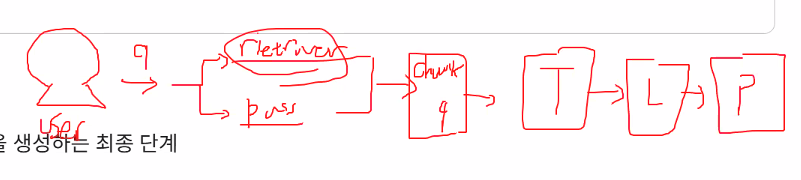

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough

In [ ]:
template = ChatPromptTemplate.from_messages([
    ('system', '당신은 직업훈련 관련 질문을 답변하는 챗봇입니다.'),
    ('system', '아래 Context를 참고해서 답변을 해주세요. 모르는 정보는 모른다고 솔직하게 이야기하세요'),
    ('system', 'context : {context}'),
    ('human', 'question : {question}')
])

In [ ]:
# 체인 구성하기
# 병렬체인구조 {}로 작성해서 사용하기
chatbot_chain = {"question" : RunnablePassthrough(),
                 "context" : retriver} | RunnablePassthrough()

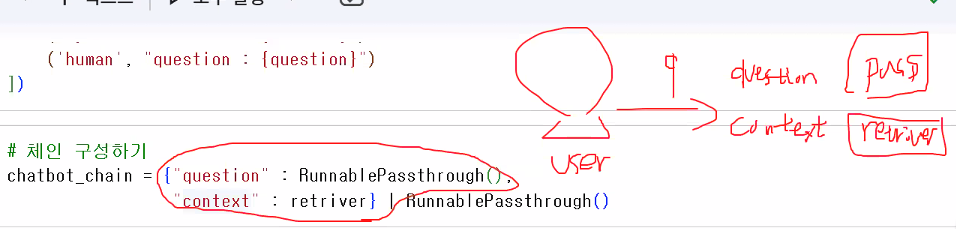

In [ ]:
chatbot_chain.invoke("KDT 단가는 얼마야?")

{'question': 'KDT 단가는 얼마야?',
 'context': [Document(metadata={'page': 1, 'creationdate': '', 'creator': 'PyPDF', 'producer': 'iLovePDF', 'total_pages': 2, 'source': '/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용/data/KDT.pdf', 'moddate': '2023-12-22T09:41:58+00:00', 'page_label': '2'}, page_content='에너지 7,686원 ②(18,150원*)첨단산업분야(12개직종)훈련과정및고성과맞춤형훈련과정인경우신청가능    * 훈련내용 및 훈련 수준 등을 검토하여 NCS단가 130%로 조정 가능-다만,첨단산업디지털선도기업은직종에관계없이단일단가(18,150원)신청가능 ③(NCS단가의300%이내또는훈련비실비*)3D프린팅,로봇,드론직종을제외한첨단산업분야(9개직종)훈련과정인경우신청가능    * NCS 단가의 300% 또는 훈련비 실비 과정은 기존 직업훈련시장에 없는 훈련과정이고 NCS 단가 130%, 18,150원 수준으로 운영이 어려운 과정에 한하여 예외적으로 인정함. 이 경우에도 심사과정에서 훈련내용 및 훈련 수준 등을 검토하여 18,150원 또는 NCS 단가 130%로 조정할 수 있음'),
  Document(metadata={'moddate': '2023-12-22T09:41:58+00:00', 'creator': 'PyPDF', 'page': 1, 'creationdate': '', 'source': '/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용/data/KDT.pdf', 'page_label': '2', 'total_pages': 2, 'producer': 'iLovePDF'}, page_content='포함되지 않는 경우 예외적으로 허용하는 과정(전체 훈련시

In [ ]:
# 체인 구성하기
chatbot_chain = {"question" : RunnablePassthrough(),
                 "context" : retriver} | template

In [ ]:
chatbot_chain.invoke("KDT 단가는 얼마야?")

ChatPromptValue(messages=[SystemMessage(content='당신은 직업훈련 관련 질문을 답변하는 챗봇입니다.', additional_kwargs={}, response_metadata={}), SystemMessage(content='아래 Context를 참고해서 답변을 해주세요. 모르는 정보는 모른다고 솔직하게 이야기하세요', additional_kwargs={}, response_metadata={}), SystemMessage(content="context : [Document(metadata={'page': 1, 'creator': 'PyPDF', 'moddate': '2023-12-22T09:41:58+00:00', 'producer': 'iLovePDF', 'creationdate': '', 'page_label': '2', 'total_pages': 2, 'source': '/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용/data/KDT.pdf'}, page_content='에너지 7,686원 ②(18,150원*)첨단산업분야(12개직종)훈련과정및고성과맞춤형훈련과정인경우신청가능    * 훈련내용 및 훈련 수준 등을 검토하여 NCS단가 130%로 조정 가능-다만,첨단산업디지털선도기업은직종에관계없이단일단가(18,150원)신청가능 ③(NCS단가의300%이내또는훈련비실비*)3D프린팅,로봇,드론직종을제외한첨단산업분야(9개직종)훈련과정인경우신청가능    * NCS 단가의 300% 또는 훈련비 실비 과정은 기존 직업훈련시장에 없는 훈련과정이고 NCS 단가 130%, 18,150원 수준으로 운영이 어려운 과정에 한하여 예외적으로 인정함. 이 경우에도 심사과정에서 훈련내용 및 훈련 수준 등을 검토하여 18,150원 또는 NCS 단가 130%로 조정할 수 있음'), Document(metadata={'creationdate': '', 'total_pages': 2, 'producer

In [ ]:
# 체인 구성하기
chatbot_chain = {"question" : RunnablePassthrough(),
                 "context" : retriver} | template | llm_4o_mini | StrOutputParser()

In [ ]:
print(chatbot_chain.invoke("KDT 단가는 얼마야?"))

KDT 단가는 여러 가지가 있으며, 아래와 같이 정리할 수 있습니다:

1. **신기술(21개 직종) 훈련 과정 기준**: NCS 단가의 130%를 적용. 분야별 평균 단가는 다음과 같습니다:
   - 디지털: 7,303원
   - 소재·부품: 7,600원
   - 로봇·드론: 7,340원
   - 바이오헬스: 7,290원
   - 에코업: 7,568원
   - 에너지: 7,686원

2. **첨단산업 분야(12개 직종) 훈련 과정 및 고성과 맞춤형 훈련 과정**: 18,150원.

또한, 첨단산업 디지털 선도 기업은 직종에 관계없이 단일 단가인 18,150원을 신청할 수 있습니다.


In [ ]:
print(chatbot_chain.invoke("KDT 직종별 단가는 얼마야?"))

KDT 직종별 단가는 다음과 같습니다:

- 디지털: 7,303원
- 소재·부품: 7,600원
- 로봇·드론: 7,340원
- 바이오헬스: 7,290원
- 에코업: 7,568원
- 에너지: 7,686원

위 단가들은 신기술 분야의 NCS 직종에 따라 적용됩니다.


In [ ]:
print(chatbot_chain.invoke("KDT 사업제안을 하려고하는데 사업유형은 어떤게 있어?"))

KDT(코리아 디지털 트레이닝) 사업제안의 경우, 다음과 같은 유형이 있습니다:

1. **디지털 신기술 아카데미**: 참여기업의 요구를 기반으로 훈련기관과 협약을 체결한 후 설계된 첨단 산업 및 디지털 분야 훈련 과정입니다.

2. **벤처 스타트업 아카데미**: 기업이 필요로 하는 인재를 양성하기 위해 벤처 또는 스타트업 등이 속한 협단체가 구성하여 운영하는 과정입니다.

3. **지역·산업 주도형 아카데미**: 지역별 및 산업별 인적자원개발 위원회가 참여기업과 훈련기관을 매칭하여 설계하고 운영하는 과정입니다.

4. **첨단 산업 디지털 선도기업 아카데미**: 첨단 산업 디지털 선도기업이 자체적으로 운영하거나, 운영 지원 기관과 함께 운영하는 훈련 과정입니다.

5. **대학 주도형 아카데미**: 고등교육법 상의 대학 또는 산학협력단이 참여기업과 협약을 체결한 후 운영하는 훈련 과정입니다.

사업 제안 시에는 이러한 유형 중에서 적합한 것을 선택하여 준비하시면 됩니다.


In [ ]:
# => 실제 문서를 기반으로 답변을 준다.

In [ ]:
# 참고해야될 문서가 많을경우
# -> 리트리버 사용하기 전에 카테고리 분류 하는것 먼저!!
# -> 분류에 맞는 벡터베이스 내에서 찾을 수 있게, 문서 벡터화